# GAN training

In [2]:
import sys
from pathlib import Path

# Add gan_model/ to path
sys.path.insert(0, "/kaggle/input/project3-code")

import torch
from config import DEVICE

# Kaggle:
IMAGES_DIR = Path("/kaggle/input/phong-dataset/images")
PARAMS_DIR = Path("/kaggle/input/phong-dataset/params")
OUTPUT_DIR = Path("/kaggle/working/output")
CKPT_DIR   = Path("/kaggle/working/checkpoints")

# Local:
# IMAGES_DIR = Path("../data/images")
# PARAMS_DIR = Path("../data/params")
# OUTPUT_DIR = Path("output")
# CKPT_DIR   = Path("checkpoints")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device     : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
print(f"Images dir : {IMAGES_DIR}  (exists: {IMAGES_DIR.exists()})")
print(f"Params dir : {PARAMS_DIR}  (exists: {PARAMS_DIR.exists()})")

Device     : cpu
Images dir : ..\data\images  (exists: True)
Params dir : ..\data\params  (exists: True)


# Dataset

In [3]:
from dataset import get_datasets

train_dataset, test_dataset = get_datasets(
    images_dir  = IMAGES_DIR,
    params_dir  = PARAMS_DIR,
)

Train: 2400 | Test: 600


# Train

Generator      params: 7,566,211
Discriminator  params: 17,734,785


Epoch 001/5  G loss=45.5290 (adv=2.1414, l1=0.4339)  D loss=1.0362  lr=1.82e-04


  └─ val  G loss=13.0541 (adv=0.9976, l1=0.1206)  D loss=0.9732  (best G=13.0541)  [saved]


Epoch 002/5  G loss=9.0113 (adv=1.1324, l1=0.0788)  D loss=0.0967  lr=1.34e-04


  └─ val  G loss=5.3252 (adv=0.4215, l1=0.0490)  D loss=0.2321  (best G=5.3252)  [saved]


...

  └─ val  G loss=4.3258 (adv=0.5436, l1=0.0378)  D loss=0.5929  (best G=4.3258)  [saved]


Epoch 004/5  G loss=4.6576 (adv=1.0113, l1=0.0365)  D loss=0.0363  lr=2.81e-05


  └─ val  G loss=4.1523 (adv=0.3192, l1=0.0383)  D loss=0.1249  (best G=4.1523)  [saved]


Epoch 005/5  G loss=4.2131 (adv=0.9995, l1=0.0321)  D loss=0.0221  lr=1.00e-05


  └─ val  G loss=4.2207 (adv=0.3739, l1=0.0385)  D loss=0.1402  (best G=4.1523)


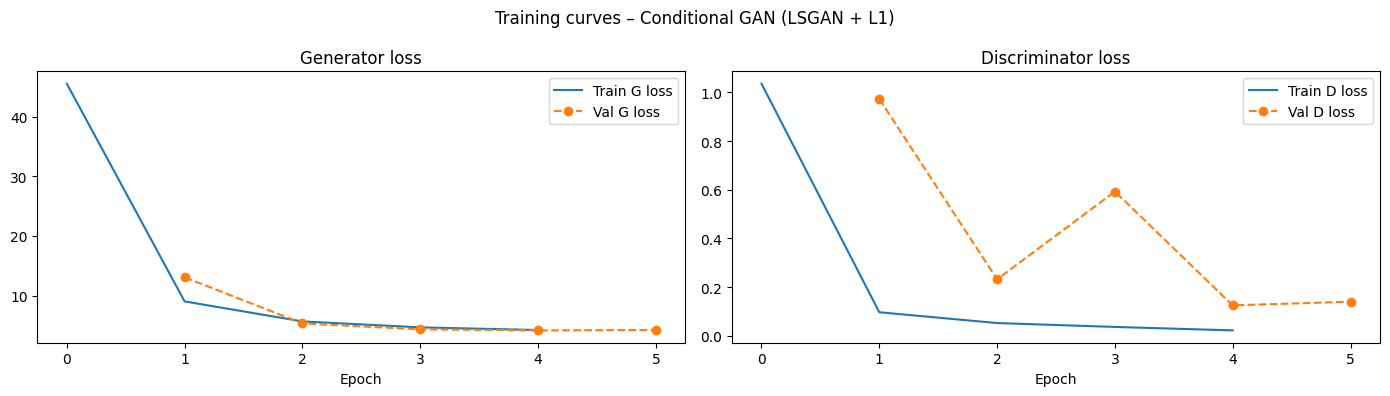


Done. Best val G loss: 4.1523 → checkpoints\G_best.pth


In [4]:
from train import train
from models import build_models

G, D = build_models(
    noise_dim  = 8,
    cond_dim   = 10,
    features_g = 64,
    features_d = 32,
    device     = DEVICE,
)

history = train(
    G, D,
    train_ds = train_dataset,
    test_ds  = test_dataset,
    output_dir   = OUTPUT_DIR,
    ckpt_dir     = CKPT_DIR,
    epochs       = 5,
    lr           = 2e-4,
    betas        = (0.5, 0.999),
    lambda_l1    = 100.0,
    batch_size   = 32,
    num_workers  = 0,
    save_every   = 1,
    device       = DEVICE,
)